# **Data Cleaning**

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [122]:
hotel=pd.read_csv('Hotel_bookings_final.csv')
hotel.head()

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,...,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No


In [123]:
hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  object 
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  object 
 5   check_in_date       24532 non-null  object 
 6   check_out_date      24532 non-null  object 
 7   room_type           30000 non-null  object 
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  object 
 10  booking_channel     30000 non-null  object 
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 non-null  object 
 16  refu

In [124]:
column_to_convert=['booking_date','check_in_date','check_out_date','travel_date']
for col in column_to_convert:
  hotel[col]=pd.to_datetime(hotel[col])

In [125]:
hotel.describe()

,customer_id,property_id,star_rating,booking_date,check_in_date,check_out_date,num_rooms_booked,booking_value,costprice,markup,selling_price,refund_amount,travel_date,cashback,coupon_redeem
count,30000.000000,30000.000000,30000.000000,30000,24532,24532,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000,30000.000000,30000.000000
mean,249.721767,3.777533,3.602033,2024-10-14 12:00:02.880000,2024-11-14 03:36:32.401760768,2024-11-18 03:46:24.086091520,1.352333,25080.525454,22541.494100,6963.32440,29504.818500,320.938376,2024-07-24 03:53:11.040000,3.831534,4.134988
min,1.000000,1.000000,2.000000,2024-04-01 00:00:00,2024-04-02 00:00:00,2024-04-04 00:00:00,1.000000,1279.770000,3822.000000,1181.00000,5003.000000,0.000000,2024-03-02 00:00:00,0.000000,-3.532183
25%,123.000000,1.000000,3.000000,2024-07-08 00:00:00,2024-08-08 00:00:00,2024-08-12 00:00:00,1.000000,15922.712500,15088.750000,4661.75000,19750.500000,0.000000,2024-05-28 00:00:00,0.000000,0.000000
50%,248.000000,3.000000,4.000000,2024-10-14 12:00:00,2024-11-16 00:00:00,2024-11-19 12:00:00,1.000000,24736.145000,22731.000000,7021.50000,29752.500000,221.141185,2024-07-23 00:00:00,1.030180,0.000000
75%,376.000000,5.000000,4.000000,2025-01-21 00:00:00,2025-02-20 00:00:00,2025-02-25 00:00:00,2.000000,33570.000000,30427.000000,9399.00000,39826.000000,594.624344,2024-09-08 00:00:00,7.378533,0.000000
max,499.000000,7.000000,5.000000,2025-04-30 00:00:00,2025-06-28 00:00:00,2025-07-03 00:00:00,3.000000,67764.460000,38200.000000,11800.00000,50000.000000,1462.725105,2025-01-29 00:00:00,21.268013,89.644917
std,145.484836,2.081471,0.860241,NaN,NaN,NaN,0.574403,11587.369335,9259.520787,2860.10657,12119.627338,339.635396,NaN,4.783590,10.846221


In [126]:
hotel[hotel['check_in_date'].isnull()]['booking_status'].value_counts()

,count
booking_status,
Cancelled,5045
Failed,423


##Sanity Check - is there any row with confirmed status and not having
5468+24532=3000 all row included

In [127]:
hotel.rename(columns={'Coupon USed?':'coupon_used'})

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,coupon_used
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaT,NaT,Deluxe,1,Leisure,...,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,91,5,Boston,4,2025-04-29,2025-05-23,2025-05-24,Standard,1,Business,...,23365,Debit Card,Yes,286.664177,Web,Confirmed,2024-10-05,0.000000,0.000000,No
29996,432,5,Los Angeles,4,2025-04-29,2025-06-24,2025-06-25,Deluxe,1,Leisure,...,22047,Bank Transfer,Yes,918.255229,iOS,Confirmed,2024-10-22,0.000000,0.000000,No
29997,15,5,Boston,5,2025-04-29,2025-06-17,2025-06-20,Standard,1,Leisure,...,26321,PayPal,Yes,417.024013,iOS,Confirmed,2024-10-22,0.000000,2.576207,Yes
29998,73,1,San Francisco,3,2025-04-29,NaT,NaT,Standard,1,Business,...,20806,Bank Transfer,Yes,468.349882,Android,Cancelled,2024-10-15,6.809804,0.000000,No


In [128]:
hotel = hotel[hotel['coupon_redeem'] >=0]
hotel

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaT,NaT,Deluxe,1,Leisure,...,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,91,5,Boston,4,2025-04-29,2025-05-23,2025-05-24,Standard,1,Business,...,23365,Debit Card,Yes,286.664177,Web,Confirmed,2024-10-05,0.000000,0.000000,No
29996,432,5,Los Angeles,4,2025-04-29,2025-06-24,2025-06-25,Deluxe,1,Leisure,...,22047,Bank Transfer,Yes,918.255229,iOS,Confirmed,2024-10-22,0.000000,0.000000,No
29997,15,5,Boston,5,2025-04-29,2025-06-17,2025-06-20,Standard,1,Leisure,...,26321,PayPal,Yes,417.024013,iOS,Confirmed,2024-10-22,0.000000,2.576207,Yes
29998,73,1,San Francisco,3,2025-04-29,NaT,NaT,Standard,1,Business,...,20806,Bank Transfer,Yes,468.349882,Android,Cancelled,2024-10-15,6.809804,0.000000,No


# **ANALYSIS Begins**

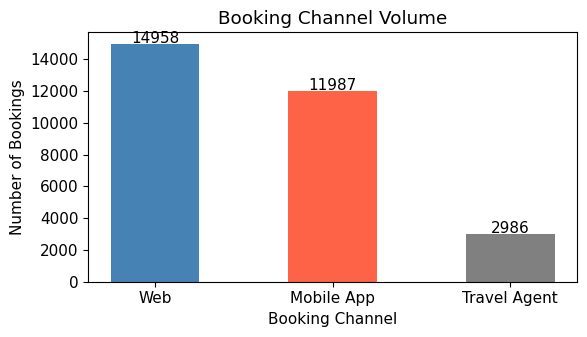

In [165]:
c=hotel.groupby('booking_channel')['customer_id'].count().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(c.index, c.values, color=['steelblue','tomato','gray'], width=0.5)
for i, v in enumerate(c.values):
    ax.text(i, v+100, str(v), ha='center')
ax.set_title('Booking Channel Volume')
ax.set_ylabel('Number of Bookings')
ax.set_xlabel('Booking Channel')
plt.tight_layout()
plt.show()


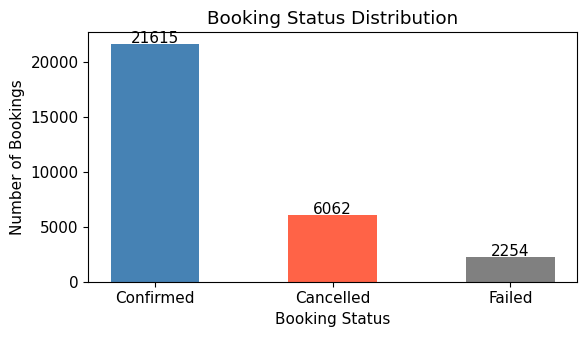

In [160]:
b = hotel['booking_status'].value_counts()
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(b.index, b.values, color=['steelblue','tomato','gray'], width=0.5)
for i, v in enumerate(b.values):
    ax.text(i, v+100, str(v), ha='center')
ax.set_title('Booking Status Distribution')
ax.set_ylabel('Number of Bookings')
ax.set_xlabel('Booking Status')
plt.tight_layout()
plt.show()


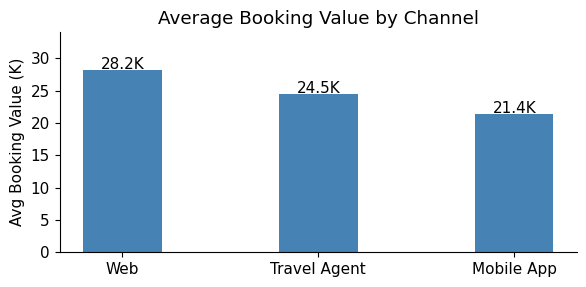

In [153]:
a=hotel.groupby('booking_channel')['booking_value'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(a.index, a.values/1000, color='steelblue', width=0.4)
for i, v in enumerate(a.values):
    ax.text(i, v/1000+0.2, f'{v/1000:.1f}K', ha='center')
ax.set_ylabel('Avg Booking Value (K)')
ax.set_title('Average Booking Value by Channel')
ax.set_ylim(0, 34)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

<Axes: title={'center': 'Room Type Wise Volume'}, xlabel='room_type'>

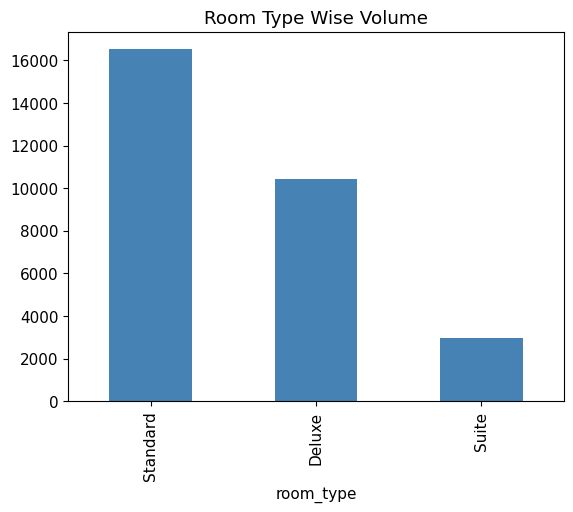

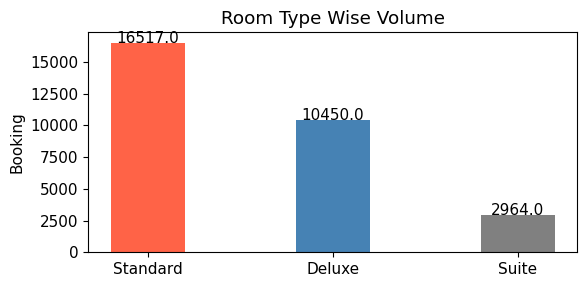

In [173]:
q=hotel.groupby('room_type')['customer_id'].count().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(q.index, q.values, color=['tomato','steelblue','gray'], width=0.4)
for i, v in enumerate(q.values):
    ax.text(i, v+0.2, f'{v:.1f}', ha='center')
ax.set_ylabel('Booking')
ax.set_title('Room Type Wise Volume')
plt.tight_layout(); plt.show()

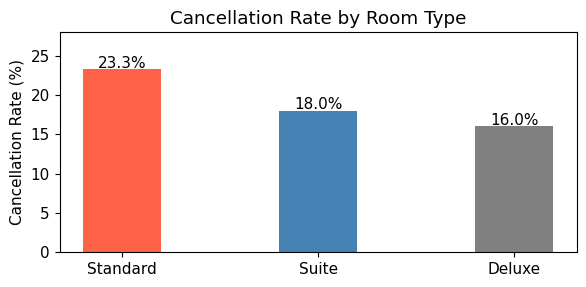

In [168]:
cancel_by_room = hotel.groupby('room_type')['booking_status'].apply(lambda x: (x == 'Cancelled').mean()*100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(cancel_by_room.index, cancel_by_room.values, color=['tomato','steelblue','gray'], width=0.4)
for i, v in enumerate(cancel_by_room.values):
    ax.text(i, v+0.2, f'{v:.1f}%', ha='center')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_title('Cancellation Rate by Room Type')
ax.set_ylim(0, 28)
plt.tight_layout(); plt.show()

In [134]:
print(hotel.groupby('room_type')['booking_value'].sum().sort_values(ascending=False))

room_type
Standard    4.154044e+08
Deluxe      2.612658e+08
Suite       7.402577e+07
Name: booking_value, dtype: float64


<Axes: title={'center': 'Star Rating Wise Booking Volume'}, xlabel='star_rating'>

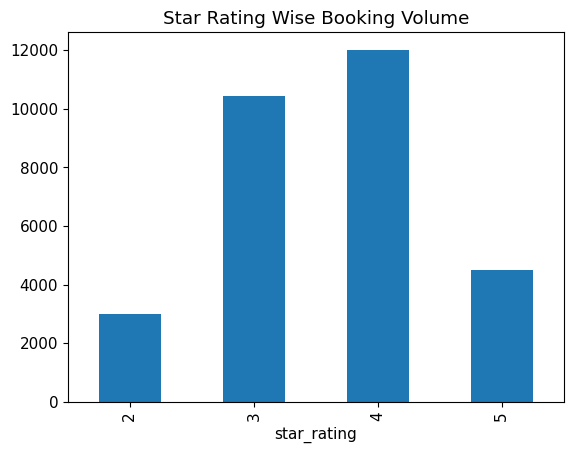

In [183]:
star_rating_volume=hotel.groupby('star_rating')['customer_id'].count().sort_values(ascending=False).sort_index()
star_rating_volume.plot(kind='bar',title='Star Rating Wise Booking Volume')

<Axes: title={'center': 'Star Rating Wise Cancellation Rate'}, xlabel='star_rating'>

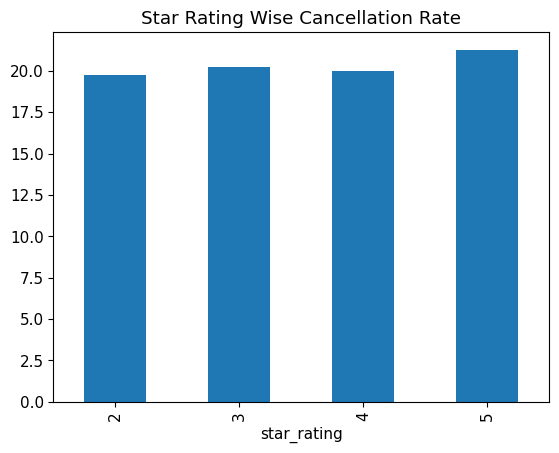

In [190]:
star_rating_cancellation_rate=hotel.groupby('star_rating')['booking_status'].apply(lambda x: (x == 'Cancelled').mean()*100)
star_rating_cancellation_rate.plot(kind='bar',title='Star Rating Wise Cancellation Rate')

In [136]:
total_booking=hotel['customer_id'].count()
cancelled_booking = len(hotel[hotel['booking_status'] == 'Cancelled'])
cancellation_rate= round(cancelled_booking/total_booking,2)
print("Cancellation Rate is ",cancellation_rate*100,"%")

Cancellation Rate is  20.0 %


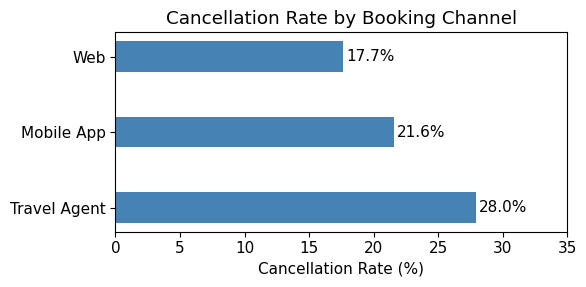

In [152]:
cancel_by_channel = hotel.groupby('booking_channel')['booking_status'].apply(lambda x: (x == 'Cancelled').mean()*100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(cancel_by_channel.index, cancel_by_channel.values, color='steelblue', height=0.4)
for i, v in enumerate(cancel_by_channel.values):
    ax.text(v+0.2, i, f'{v:.1f}%', va='center')
ax.set_xlabel('Cancellation Rate (%)')
ax.set_title('Cancellation Rate by Booking Channel')
ax.set_xlim(0, 35)
plt.tight_layout(); plt.show()

In [141]:
hotel['year_month'] = hotel['check_in_date'].dt.to_period('M')
monthly_average_booking_value = hotel.groupby('year_month')['booking_value'].mean().sort_index()
monthly_booking_value = hotel.groupby('year_month')['booking_value'].sum().sort_index()
print("Monthly Average booking value per month")
print(monthly_average_booking_value)

Monthly Average booking value per month
year_month
2024-04    21975.571809
2024-05    22641.536835
2024-06    23605.866573
2024-07    24100.857667
2024-08    25337.501545
2024-09    25814.294605
2024-10    24825.009089
2024-11    25230.050245
2024-12    25071.596884
2025-01    24131.004258
2025-02    24303.355355
2025-03    26273.864736
2025-04    27763.178464
2025-05    27779.467386
2025-06    27883.586359
Freq: M, Name: booking_value, dtype: float64


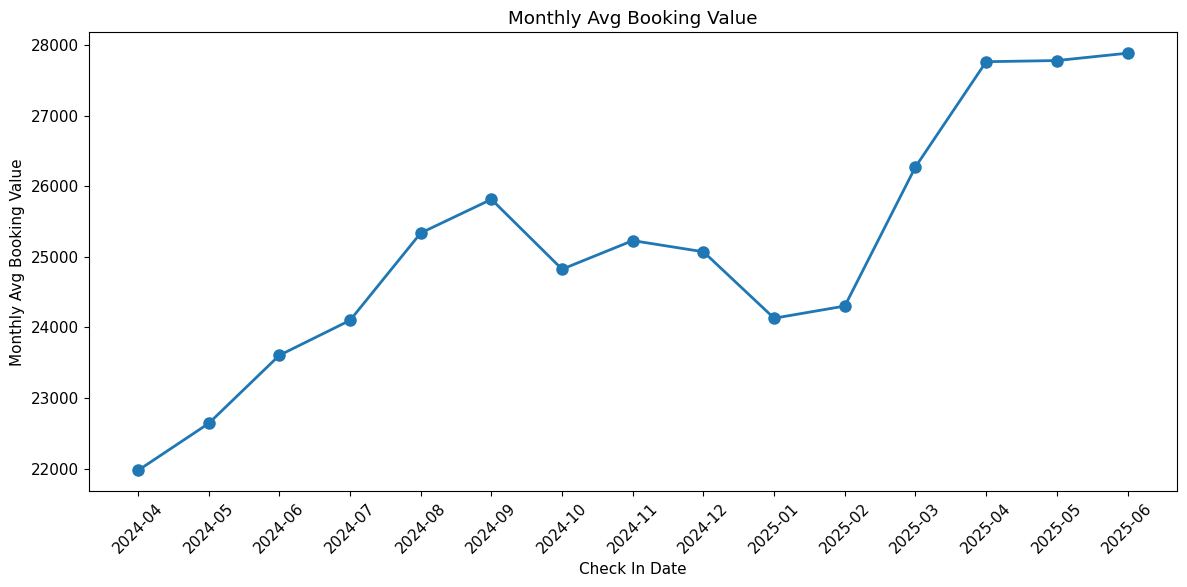

In [142]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_average_booking_value.index.astype(str), monthly_average_booking_value.values, marker='o', linewidth=2, markersize=8)
ax.set_title('Monthly Avg Booking Value')
ax.set_ylabel('Monthly Avg Booking Value')
ax.set_xlabel('Check In Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [143]:
print("Monthly Total booking value")
print(monthly_booking_value)

Monthly Total booking value
year_month
2024-04    10328518.75
2024-05    34120796.01
2024-06    42089260.10
2024-07    46273646.72
2024-08    48546652.96
2024-09    48040402.26
2024-10    45802141.77
2024-11    48492156.57
2024-12    48438325.18
2025-01    47151982.32
2025-02    42117714.83
2025-03    51260310.10
2025-04    51139774.73
2025-05    38891254.34
2025-06    12101476.48
Freq: M, Name: booking_value, dtype: float64


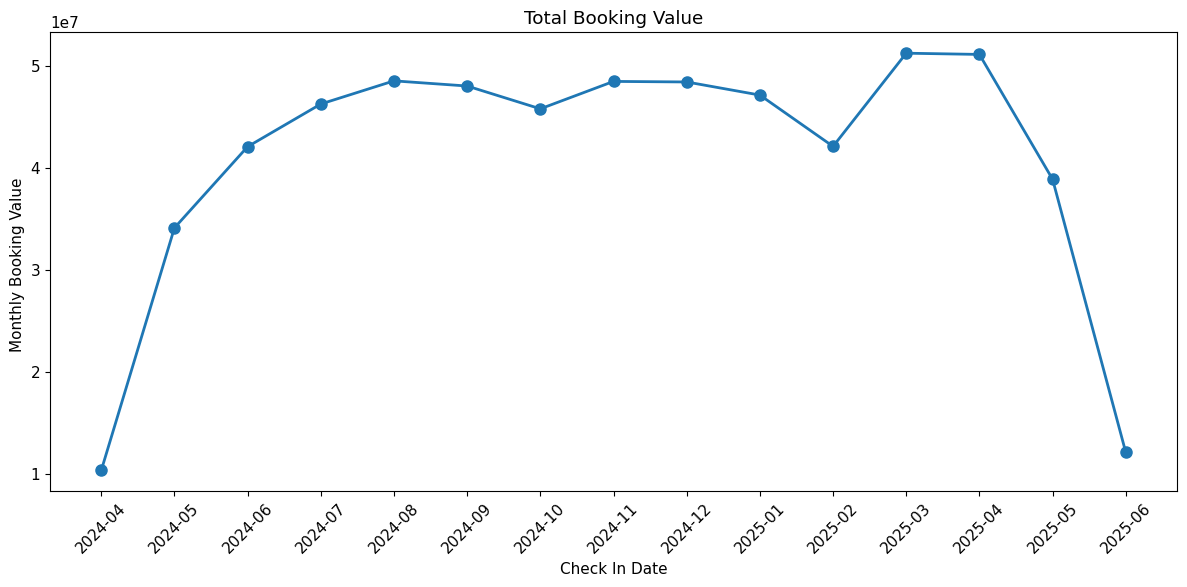

In [144]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_booking_value.index.astype(str), monthly_booking_value.values, marker='o', linewidth=2, markersize=8)
ax.set_title('Total Booking Value')
ax.set_ylabel('Monthly Booking Value ')
ax.set_xlabel('Check In Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

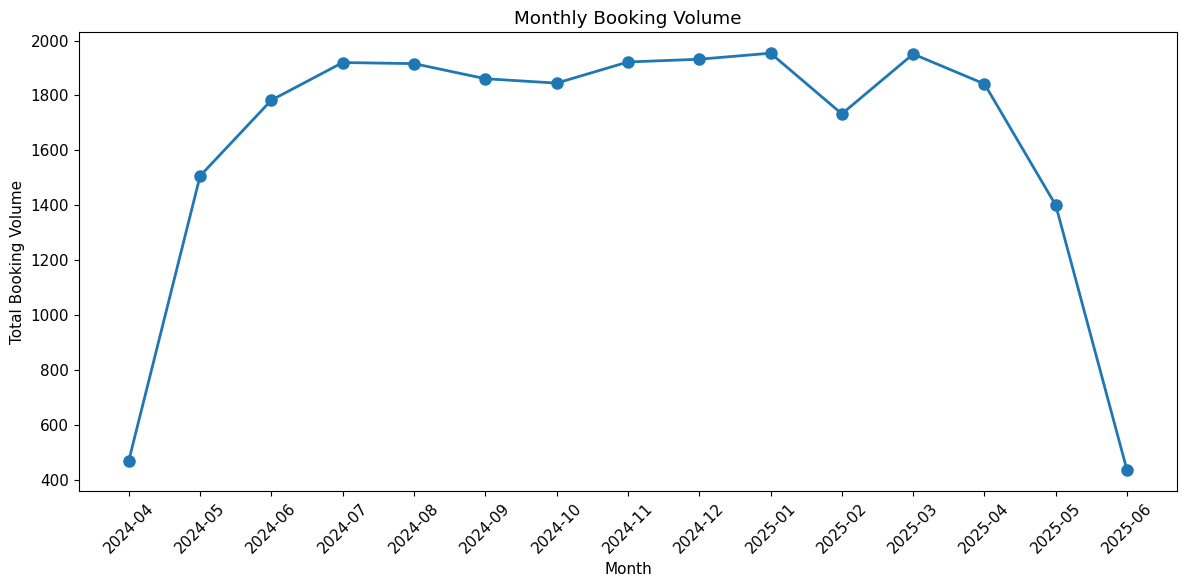

In [174]:
Monthly_volume_of_bookings = hotel.groupby('year_month')['customer_id'].count().sort_index()
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(Monthly_volume_of_bookings.index.astype(str), Monthly_volume_of_bookings.values, marker='o', linewidth=2, markersize=8)
ax.set_title('Monthly Booking Volume')
ax.set_ylabel('Total Booking Volume')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [147]:
hotel['length_of_stay'] = (hotel['check_out_date'] - hotel['check_in_date']).dt.days
stay_length_by_month=hotel.groupby('year_month')['length_of_stay'].mean().sort_index()
print("Monthly Average length of stay per month")
print(stay_length_by_month)

Monthly Average length of stay per month
year_month
2024-04    4.127660
2024-05    4.037823
2024-06    3.988783
2024-07    4.030208
2024-08    4.039144
2024-09    4.013434
2024-10    3.982114
2024-11    3.965661
2024-12    4.060559
2025-01    3.928864
2025-02    4.010387
2025-03    4.015377
2025-04    4.002714
2025-05    3.996429
2025-06    3.981567
Freq: M, Name: length_of_stay, dtype: float64


In [148]:
print("Average length of stay per month",stay_length_by_month.mean())

Average length of stay per month 4.012048178519142


# **B2B Business**

In [194]:
total_order_per_user=hotel['customer_id'].value_counts()
repeat_cus=(total_order_per_user>1).count()
avg_repeat_bookings=total_order_per_user[total_order_per_user>1].mean()
total_user=len(total_order_per_user)
print("Average Repeat Bookings are ",avg_repeat_bookings)


Average Repeat Bookings are  59.98196392785571
